# Web Attack Detection on CIC-IDS-2017 — Complete System

**CSLab Challenge — Detecting Web Attacks (Brute Force, XSS, SQL Injection)**

The web attacks in this dataset were generated against **DVWA** (a deliberately vulnerable PHP/MySQL web app) acting as the victim, with **XSS attacks automated via Selenium**. Our task is to **detect these attacks from the recorded network flows**.

This notebook builds a complete Intrusion Detection System with **three detection approaches**:

| # | Technique | Paradigm | What it detects |
|---|-----------|----------|-----------------|
| 1 | **XGBoost** | Supervised (per-flow) | Known web-attack patterns |
| 2 | **Isolation Forest** | Unsupervised anomaly (per-flow) | Abnormal / novel flows |
| 3 | **Conditional Random Field (CRF)** | Probabilistic Graphical Model (sequence) | Attacks in their temporal sequence |

The CRF is the **sequence layer**: unlike layers 1–2 which look at each flow alone, a CRF is a Probabilistic Graphical Model that labels each flow **in the context of the flows around it** — capturing the sequential nature of a real attack (Brute Force → XSS → SQL Injection).

**Dataset:** `Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv` from the **GeneratedLabelledFlows** version (keeps `Timestamp`, `Source IP`, `Destination IP`).


## Step 0 — Install & import libraries

In [ ]:
!pip install xgboost shap imbalanced-learn sklearn-crfsuite -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import sklearn_crfsuite
import shap

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
print("Libraries imported.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
Libraries imported.


## Step 1 — Load the dataset

Upload `Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv` from the **GeneratedLabelledFlows / TrafficLabelling** folder. This version is usually `latin1`-encoded, so we read it robustly.

In [ ]:
from google.colab import files
uploaded = files.upload()
import io
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]), encoding='latin1', low_memory=False)
df.columns = df.columns.str.strip()
print("Loaded:", fname, "| Shape:", df.shape)


Saving Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv to Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv | Shape: (458968, 85)


In [ ]:
# Confirm the temporal columns exist (needed for the CRF sequence layer)
for col in ['Flow ID','Source IP','Destination IP','Timestamp','Protocol','Label']:
    print(f"{col:16s}: {'PRESENT' if col in df.columns else 'MISSING'}")
print("\nLabels:")
print(df['Label'].value_counts())


Flow ID         : PRESENT
Source IP       : PRESENT
Destination IP  : PRESENT
Timestamp       : PRESENT
Protocol        : PRESENT
Label           : PRESENT

Labels:
Label
BENIGN                        168186
Web Attack  Brute Force        1507
Web Attack  XSS                 652
Web Attack  Sql Injection        21
Name: count, dtype: int64


## Step 2 — Clean & prepare

We separate the metadata (IP, timestamp) from the numeric features, force everything numeric, and drop broken rows.

In [ ]:
df['Label'] = df['Label'].astype(str).str.strip()
df['binary_label'] = df['Label'].apply(lambda x: 0 if x.upper()=='BENIGN' else 1)

meta_cols = [c for c in ['Flow ID','Source IP','Source Port','Destination IP',
                         'Destination Port','Protocol','Timestamp'] if c in df.columns]

drop_cols = set(meta_cols + ['Label','binary_label'])
feature_df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
feature_df = feature_df.apply(pd.to_numeric, errors='coerce')
feature_df.replace([np.inf,-np.inf], np.nan, inplace=True)

good_rows = feature_df.notna().all(axis=1)
print(f"Dropping {int((~good_rows).sum())} bad rows of {len(df)}")
df = df[good_rows].reset_index(drop=True)
feature_df = feature_df[good_rows].reset_index(drop=True)
feature_names = feature_df.columns.tolist()

# Sort chronologically for the sequence layer later
if 'Timestamp' in df.columns:
    df['Timestamp_parsed'] = pd.to_datetime(df['Timestamp'], errors='coerce', dayfirst=True)
    order = df['Timestamp_parsed'].argsort(kind='stable').values
    df = df.iloc[order].reset_index(drop=True)
    feature_df = feature_df.iloc[order].reset_index(drop=True)
    print("Sorted by time:", df['Timestamp_parsed'].min(), "->", df['Timestamp_parsed'].max())

print("Numeric features:", len(feature_names), "| attacks:", int(df['binary_label'].sum()))


Dropping 288737 bad rows of 458968
Sorted by time: 2017-07-06 08:59:00 -> 2017-07-06 12:59:00
Numeric features: 77 | attacks: 2180


## Step 3 — Class distribution (the imbalance)

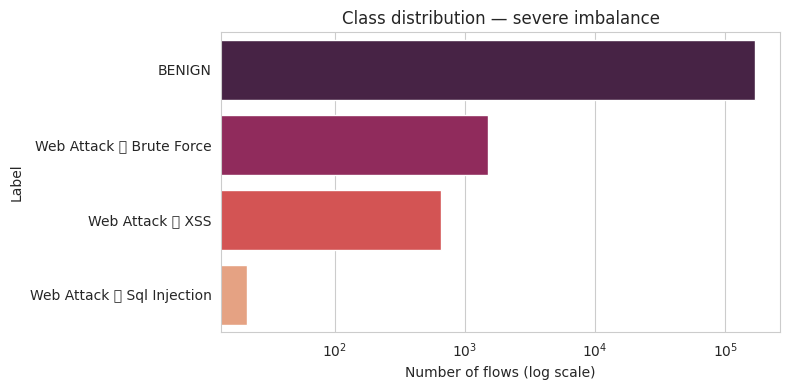

Label
BENIGN                        168051
Web Attack  Brute Force        1507
Web Attack  XSS                 652
Web Attack  Sql Injection        21
Name: count, dtype: int64


In [ ]:
counts = df['Label'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=counts.values, y=counts.index, palette='rocket')
plt.xscale('log'); plt.xlabel('Number of flows (log scale)')
plt.title('Class distribution — severe imbalance')
plt.tight_layout(); plt.savefig('fig_class_distribution.png', dpi=150); plt.show()
print(counts)


---
# PART A — Per-flow detection (XGBoost + Isolation Forest)

## A1 — Split, scale, balance

In [ ]:
X = feature_df.values
y = df['binary_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_bal, y_train_bal = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("After SMOTE:", dict(pd.Series(y_train_bal).value_counts()))


Train: (119161, 77) Test: (51070, 77)
After SMOTE: {0: np.int64(117635), 1: np.int64(117635)}


## A2 — Metric helper (collects all results)

In [ ]:
results = []
def evaluate(name, y_true, y_pred):
    r = {'Model':name,
         'Accuracy': round(accuracy_score(y_true,y_pred),4),
         'Precision':round(precision_score(y_true,y_pred,zero_division=0),4),
         'Recall':   round(recall_score(y_true,y_pred,zero_division=0),4),
         'F1':       round(f1_score(y_true,y_pred,zero_division=0),4)}
    print(f"{name}: Acc {r['Accuracy']} | Prec {r['Precision']} | Rec {r['Recall']} | F1 {r['F1']}")
    return r


## A3 — Layer 1: XGBoost (supervised)

In [ ]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_bal, y_train_bal)
y_pred_xgb  = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:,1]
results.append(evaluate("XGBoost (supervised)", y_test, y_pred_xgb))
print("\n", classification_report(y_test, y_pred_xgb, target_names=['BENIGN','WEB ATTACK']))


XGBoost (supervised): Acc 0.9997 | Prec 0.9789 | Rec 0.9954 | F1 0.9871

               precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     50416
  WEB ATTACK       0.98      1.00      0.99       654

    accuracy                           1.00     51070
   macro avg       0.99      1.00      0.99     51070
weighted avg       1.00      1.00      1.00     51070



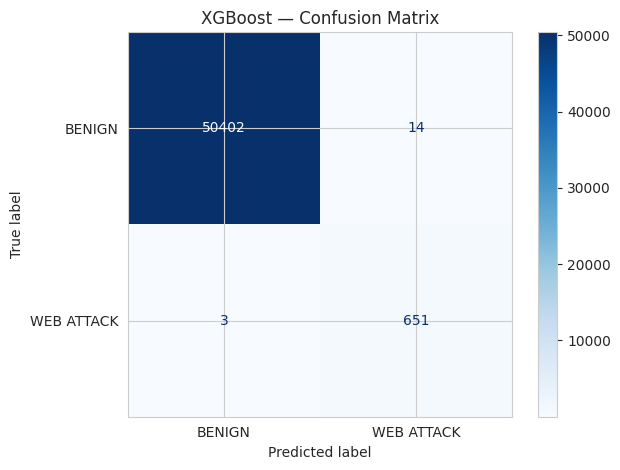

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['BENIGN','WEB ATTACK']).plot(cmap='Blues', values_format='d')
plt.title('XGBoost — Confusion Matrix'); plt.tight_layout()
plt.savefig('fig_cm_xgb.png', dpi=150); plt.show()


## A4 — Layer 2: Isolation Forest (unsupervised anomaly)

In [ ]:
contam = float(y_train.mean())
iso = IsolationForest(n_estimators=200, contamination=contam, random_state=42, n_jobs=-1)
iso.fit(X_train_scaled)
y_pred_iso = np.where(iso.predict(X_test_scaled)==-1, 1, 0)
results.append(evaluate("Isolation Forest (anomaly)", y_test, y_pred_iso))


Isolation Forest (anomaly): Acc 0.9751 | Prec 0.0469 | Rec 0.0489 | F1 0.0479


## A5 — Combined (OR fusion)

In [ ]:
y_pred_or = np.where((y_pred_xgb==1)|(y_pred_iso==1), 1, 0)
results.append(evaluate("Combined: OR (semi-supervised)", y_test, y_pred_or))


Combined: OR (semi-supervised): Acc 0.9869 | Prec 0.4947 | Rec 0.9954 | F1 0.6609


---
# PART B — Sequence detection with a CRF (Probabilistic Graphical Model)

**Why a CRF.** Layers 1–2 classify each flow in isolation. A **Conditional Random Field** is a Probabilistic Graphical Model that labels each flow **in the context of neighbouring flows** in the time-ordered sequence. It models attacks as part of a temporal pattern, not isolated events.

**The recipe (state of the art for sequence labeling):**
1. Order flows by time (done in Step 2).
2. Select the most informative features and **discretise** them into bins (CRFs use discrete features).
3. For each flow, build a feature dictionary that also includes its **previous and next** flow's features (neighbour context).
4. Chop the timeline into short sequences and train the CRF to label each flow attack/benign.
5. Evaluate with a **blocked split** so attacks appear in both train and test (a plain time-split would put all attacks in one half).

## B1 — Discretise features for the CRF

In [ ]:
# Scale, then keep the 25 highest-variance features, then bin into 6 levels each
X_all_scaled = StandardScaler().fit_transform(feature_df.values)
var = X_all_scaled.var(axis=0)
top_idx = np.argsort(var)[-25:]
X_top = X_all_scaled[:, top_idx]

kbin = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='quantile',
                        subsample=200000, random_state=42)
X_binned = kbin.fit_transform(X_top).astype(int)
n_feat = X_binned.shape[1]
print("Discretised feature matrix:", X_binned.shape)


Discretised feature matrix: (170231, 25)


## B2 — Build sequences with neighbour context

In [ ]:
y_seq_all = df['binary_label'].values
L = 60   # sequence length (flows per sequence)

def feats_for(i, t, start):
    idx = start + t
    d = {f'f{j}': str(X_binned[idx, j]) for j in range(n_feat)}
    if t > 0:                       # previous flow's features
        for j in range(n_feat): d[f'-1f{j}'] = str(X_binned[idx-1, j])
    if t < L-1:                     # next flow's features
        for j in range(n_feat): d[f'+1f{j}'] = str(X_binned[idx+1, j])
    return d

def to_sequences(L):
    Xs, Ys = [], []
    for i in range(0, len(X_binned)-L, L):
        Xs.append([feats_for(i, t, i) for t in range(L)])
        Ys.append([str(v) for v in y_seq_all[i:i+L]])
    return Xs, Ys

X_seq, Y_seq = to_sequences(L)
print("Number of sequences:", len(X_seq), "| each of length", L)


Number of sequences: 2837 | each of length 60


## B3 — Blocked split (attacks in both train and test)

In [ ]:
n_blocks = 10
block_id = np.arange(len(X_seq)) // (len(X_seq)//n_blocks + 1)
test_blocks = [1, 4, 7]                       # ~30% for test
is_test = np.isin(block_id, test_blocks)

X_seq_tr = [s for s,t in zip(X_seq, is_test) if not t]
Y_seq_tr = [s for s,t in zip(Y_seq, is_test) if not t]
X_seq_te = [s for s,t in zip(X_seq, is_test) if t]
Y_seq_te = [s for s,t in zip(Y_seq, is_test) if t]

atk_tr = sum(lbl.count('1') for lbl in Y_seq_tr)
atk_te = sum(lbl.count('1') for lbl in Y_seq_te)
print(f"Train sequences: {len(X_seq_tr)} (attacks: {atk_tr})")
print(f"Test sequences:  {len(X_seq_te)} (attacks: {atk_te})")


Train sequences: 1985 (attacks: 1014)
Test sequences:  852 (attacks: 1166)


## B4 — Train the CRF and evaluate

In [ ]:
crf = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=0.05, c2=0.05,
                           max_iterations=100, all_possible_transitions=True)
crf.fit(X_seq_tr, Y_seq_tr)
pred_seq = crf.predict(X_seq_te)

# flatten sequences back to flat arrays for scoring
y_crf_true = np.array([int(v) for seq in Y_seq_te for v in seq])
y_crf_pred = np.array([int(v) for seq in pred_seq for v in seq])
results.append(evaluate("CRF (sequence / PGM)", y_crf_true, y_crf_pred))


CRF (sequence / PGM): Acc 0.9934 | Prec 0.9098 | Rec 0.7873 | F1 0.8441


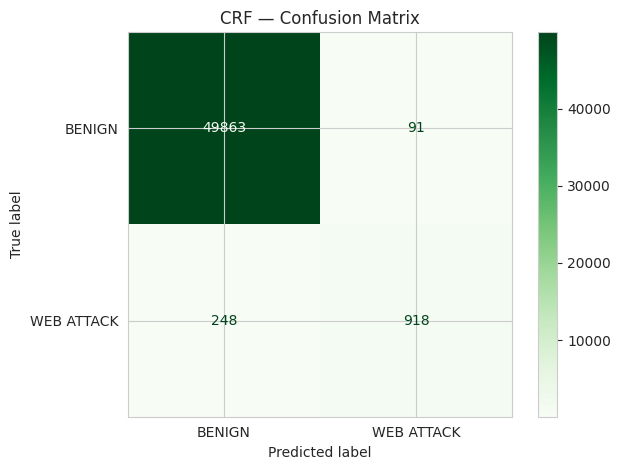

In [ ]:
cm2 = confusion_matrix(y_crf_true, y_crf_pred)
ConfusionMatrixDisplay(cm2, display_labels=['BENIGN','WEB ATTACK']).plot(cmap='Greens', values_format='d')
plt.title('CRF — Confusion Matrix'); plt.tight_layout()
plt.savefig('fig_cm_crf.png', dpi=150); plt.show()


## B5 — Visualise the CRF detections over the sequence

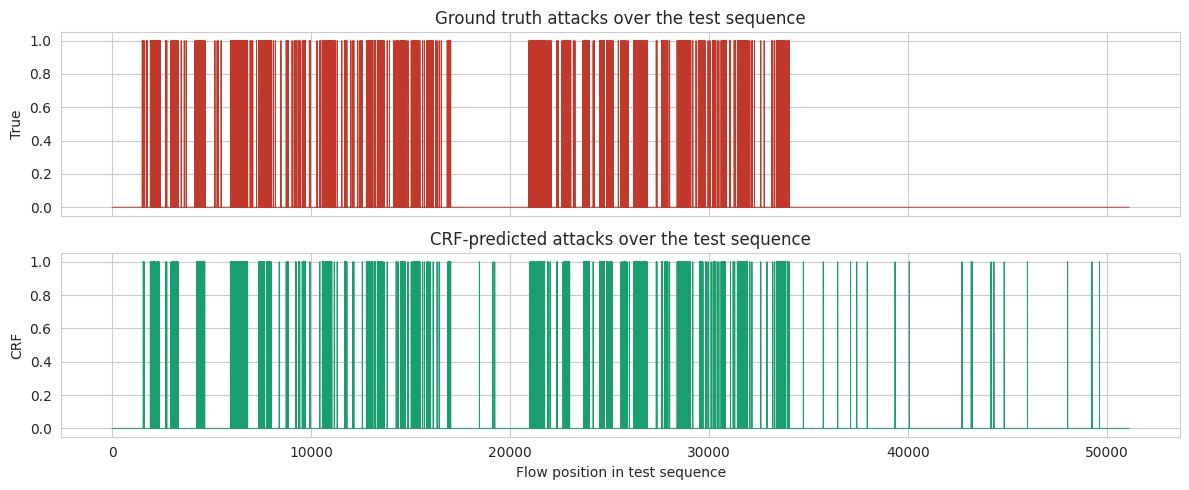

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(12,5), sharex=True)
ax[0].plot(y_crf_true, color='#c0392b', linewidth=0.7)
ax[0].set_ylabel('True'); ax[0].set_title('Ground truth attacks over the test sequence')
ax[1].plot(y_crf_pred, color='#199e70', linewidth=0.7)
ax[1].set_ylabel('CRF'); ax[1].set_xlabel('Flow position in test sequence')
ax[1].set_title('CRF-predicted attacks over the test sequence')
plt.tight_layout(); plt.savefig('fig_crf_sequence.png', dpi=150); plt.show()


---
# PART C — Compare all models, explainability, save

## C1 — Results table for ALL models

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())
results_df.to_csv('results_all_models.csv')
results_df


                                Accuracy  Precision  Recall      F1
Model                                                              
XGBoost (supervised)              0.9997     0.9789  0.9954  0.9871
Isolation Forest (anomaly)        0.9751     0.0469  0.0489  0.0479
Combined: OR (semi-supervised)    0.9869     0.4947  0.9954  0.6609
CRF (sequence / PGM)              0.9934     0.9098  0.7873  0.8441


,Accuracy,Precision,Recall,F1
Model,,,,
XGBoost (supervised),0.9997,0.9789,0.9954,0.9871
Isolation Forest (anomaly),0.9751,0.0469,0.0489,0.0479
Combined: OR (semi-supervised),0.9869,0.4947,0.9954,0.6609
CRF (sequence / PGM),0.9934,0.9098,0.7873,0.8441


## C2 — Comparison bar chart (all algorithms)

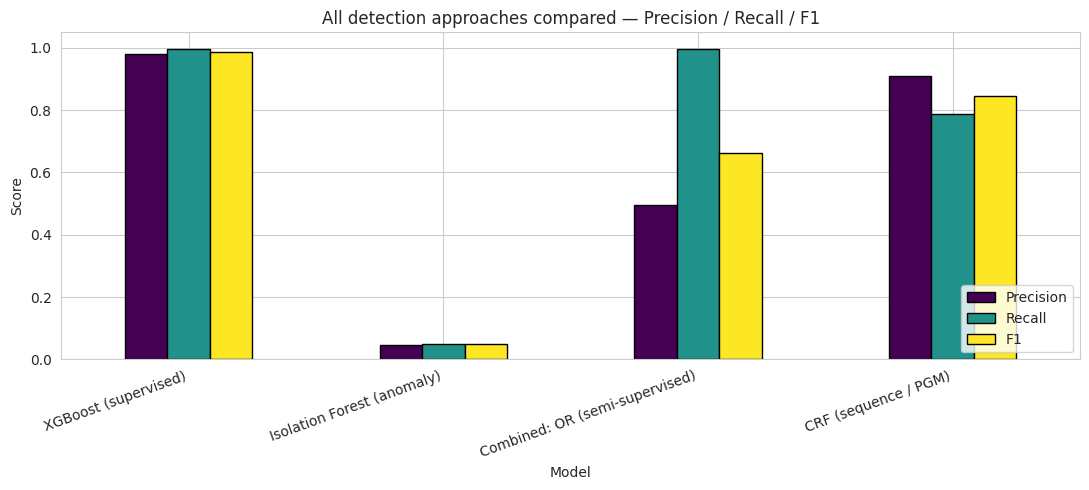

In [ ]:
ax = results_df[['Precision','Recall','F1']].plot(kind='bar', figsize=(11,5),
        colormap='viridis', edgecolor='black')
plt.title('All detection approaches compared — Precision / Recall / F1')
plt.ylabel('Score'); plt.ylim(0,1.05); plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('fig_all_models_comparison.png', dpi=150); plt.show()


## C3 — ROC curve (XGBoost)

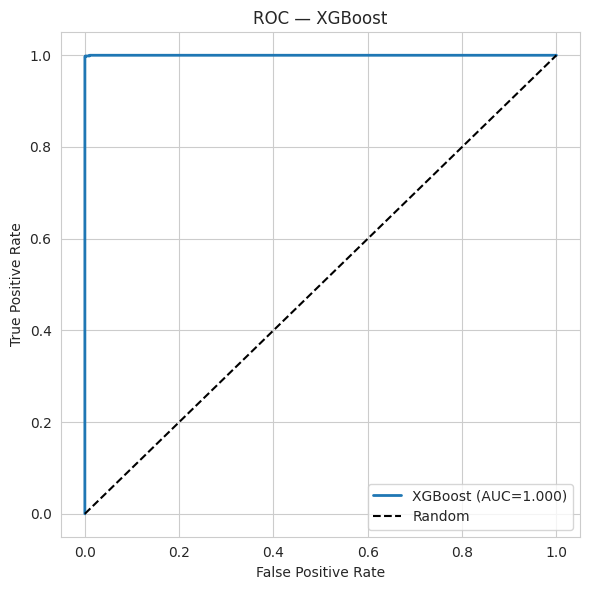

AUC: 1.0


In [ ]:
fpr,tpr,_ = roc_curve(y_test, y_proba_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f'XGBoost (AUC={auc:.3f})',lw=2)
plt.plot([0,1],[0,1],'k--',label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC — XGBoost'); plt.legend()
plt.tight_layout(); plt.savefig('fig_roc.png', dpi=150); plt.show()
print("AUC:", round(auc,4))


## C4 — SHAP explainability (which features signal an attack)

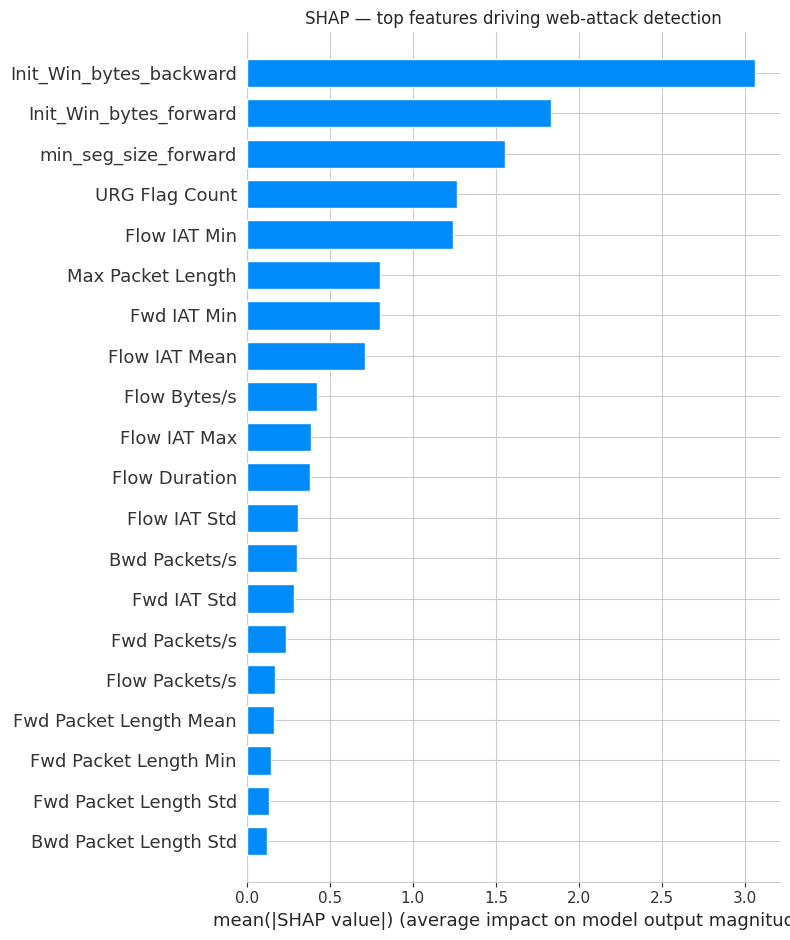

In [ ]:
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
sample = X_test_df.sample(min(2000,len(X_test_df)), random_state=42)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.title('SHAP — top features driving web-attack detection'); plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight'); plt.show()


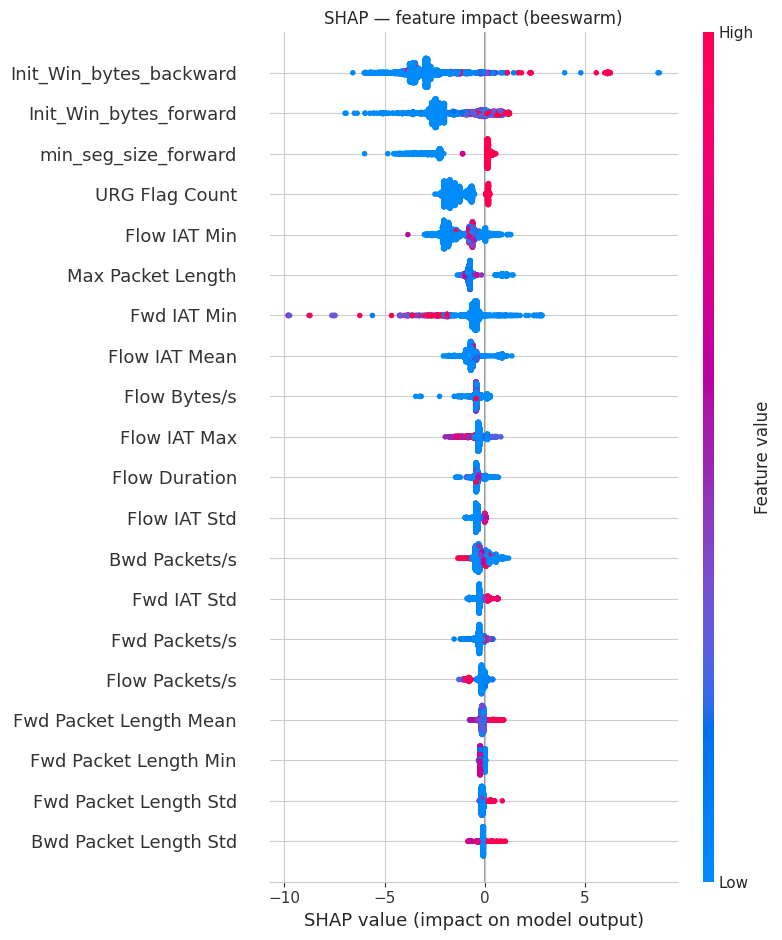

In [ ]:
shap.summary_plot(shap_values, sample, show=False)
plt.title('SHAP — feature impact (beeswarm)'); plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
mean_abs = np.abs(shap_values).mean(axis=0)
top = (pd.DataFrame({'feature':feature_names,'importance':mean_abs})
       .sort_values('importance',ascending=False).head(10).reset_index(drop=True))
print("TOP 10 features signalling a web attack:\n")
print(top.to_string(index=False))
top.to_csv('top_features.csv', index=False)


TOP 10 features signalling a web attack:

                feature  importance
Init_Win_bytes_backward    3.056108
 Init_Win_bytes_forward    1.831580
   min_seg_size_forward    1.555270
         URG Flag Count    1.266912
           Flow IAT Min    1.241315
      Max Packet Length    0.803530
            Fwd IAT Min    0.800927
          Flow IAT Mean    0.712491
           Flow Bytes/s    0.421020
           Flow IAT Max    0.389297


## C5 — Save models for the app

In [ ]:
xgb.save_model('model_xgboost.json')
import joblib
joblib.dump(iso,           'model_isoforest.joblib')
joblib.dump(scaler,        'scaler.joblib')
joblib.dump(feature_names, 'feature_names.joblib')
joblib.dump(crf,           'model_crf.joblib')
joblib.dump(kbin,          'crf_binner.joblib')
joblib.dump(top_idx,       'crf_top_idx.joblib')
print("Saved all models.")

from google.colab import files
for f in ['model_xgboost.json','model_isoforest.joblib','scaler.joblib','feature_names.joblib',
          'model_crf.joblib','crf_binner.joblib','crf_top_idx.joblib',
          'results_all_models.csv','top_features.csv']:
    files.download(f)


Saved all models.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary — three complementary detectors

1. **XGBoost** (supervised) — the strong backbone for known web attacks.
2. **Isolation Forest** (unsupervised) — a safety net for novel anomalies.
3. **CRF** (Probabilistic Graphical Model) — the sequence layer, labelling each flow in the context of neighbouring flows over time, addressing the "sequence of attacks" angle.

Plus SMOTE for imbalance, a leak-free evaluation (stratified split for per-flow models, blocked split for the CRF), and SHAP explainability. This covers three angles: *known attacks*, *novel anomalies*, and *temporal sequences*.
